In [11]:
#Plan :

#Task & dataset pick (done)
#Load & merge files (done)
#Clean headers & numeric conversion (done)
#Baseline numeric-only model (done)
#5. Feature engineering & categorical encoding (this step) Done (clean dataset + prepare features).done

import pandas as pd

# Load the dataset and use the first row as column names
df = pd.read_excel(r"C:/Users/THARUN/ML_assignment/archive/data_win_prediction_1.xlsx", header=1)

print("Columns:", df.columns.tolist())
print(df.head())

Columns: ['team a', 'de_mirage', 58.86486486486486, 0.7263078236130868, 1720.4, 47.28921568627451, 0.7926147058823529, 1536, '1-051c5a18-6a99-4e5e-bef7-ed1143474b33']
   team a   de_mirage  58.864865  0.726308  1720.4  47.289216  0.792615  1536  \
0  team a  de_inferno  52.341629  0.764807  1989.6  54.823232  0.762641  2073   
1  team b  de_vertigo  20.202020  0.773030   753.8  66.095238  0.722705   158   
2  team b   de_mirage  48.414652  0.733409  2565.0  62.631108  0.838246  2219   
3  team b   de_mirage  43.571196  0.709982  1484.4  55.513072  0.768946  1352   
4  team b   de_anubis  29.802198  0.596095  1443.4  45.317460  0.690571  1632   

   1-051c5a18-6a99-4e5e-bef7-ed1143474b33  
0  1-8f29e3ec-f49d-4d05-8eac-98993126c405  
1  1-0e83d2d4-9aef-4b16-8142-7105abbb9022  
2  1-34674634-6bc9-45bc-b022-3f3161d5aede  
3  1-a9869c55-52a9-45a8-beb6-1fdffed4506d  
4  1-f4f59665-2fb0-46e9-a617-7003bb038bc2  


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor  # since target looks numeric (MMR/score)

# Drop non-numeric/string columns (team names, map names, IDs, etc.)
df = df.select_dtypes(include=['float64', 'int64'])

# Define features and target
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column as target (skill/MMR)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate
print("Training Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))


Training Score: 0.9434715682865924
Test Score: 0.6102023669125368


In [19]:
# --- Step 5 FIX: Cleaner preprocessing ---

# 1. Reload merged dataframe
import pandas as pd, glob, os
path = r"C:/Users/THARUN/ML_assignment/archive/"
files = glob.glob(os.path.join(path, "data_win_prediction_*.xlsx"))
df = pd.concat([pd.read_excel(f, header=1) for f in files], ignore_index=True)
print("Initial shape:", df.shape)

# 2. Clean column names
df.columns = df.columns.astype(str)

# 3. Drop junk columns (float-like headers or UUIDs)
drop_cols = [c for c in df.columns if c.replace('.', '', 1).isdigit()]  # weird float headers
drop_cols += [c for c in df.columns if '-' in c and len(c) > 10]       # UUID-like
print("Dropping suspicious columns:", drop_cols[:15], "...")
df = df.drop(columns=drop_cols, errors="ignore")

# 4. Keep only useful columns (manually pick from what you saw)
keep_candidates = [
    'map', 'team a', 'team b', 'win',
    'Team_A_avg_win_percentage', 'Team_A_avg_KR', 'Team_A_avg_elo',
    'Team_B_avg_win_percentage', 'Team_B_avg_KR', 'Team_B_avg_elo'
]
df = df[[c for c in keep_candidates if c in df.columns]]
print("Kept columns:", df.columns.tolist())

# 5. Convert numeric features
num_cols = ['Team_A_avg_win_percentage','Team_A_avg_KR','Team_A_avg_elo',
            'Team_B_avg_win_percentage','Team_B_avg_KR','Team_B_avg_elo']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 6. Drop rows missing target (`win`)
df = df.dropna(subset=['win'])
print("Shape after dropping NaN win rows:", df.shape)

# 7. Encode categoricals (map, teams)
from sklearn.preprocessing import LabelEncoder
for c in ['map','team a','team b']:
    if c in df.columns:
        df[c] = df[c].astype(str)
        le = LabelEncoder()
        df[c] = le.fit_transform(df[c])

# 8. Define X, y
X = df.drop(columns=['win'])   # features
y = df['win']                  # target: match outcome (0/1)

# 9. Split + scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFinal feature columns:", X.columns.tolist())
print("X_train shape:", X_train_scaled.shape)
print("y_train value counts:\n", y_train.value_counts())


Initial shape: (12123, 50)
Dropping suspicious columns: ['58.86486486486486', '0.7263078236130868', '1720.4', '47.28921568627451', '0.7926147058823529', '1536', '38.08941058941058', '0.812422077922078', '1231.2', '49.42982456140351', '0.7192236842105265', '1092', '57.80952380952381', '0.7796571428571429', '1383.4'] ...
Kept columns: ['map', 'team a', 'team b', 'win', 'Team_A_avg_win_percentage', 'Team_A_avg_KR', 'Team_A_avg_elo', 'Team_B_avg_win_percentage', 'Team_B_avg_KR', 'Team_B_avg_elo']
Shape after dropping NaN win rows: (3601, 10)

Final feature columns: ['map', 'team a', 'team b', 'Team_A_avg_win_percentage', 'Team_A_avg_KR', 'Team_A_avg_elo', 'Team_B_avg_win_percentage', 'Team_B_avg_KR', 'Team_B_avg_elo']
X_train shape: (2880, 9)
y_train value counts:
 win
win       1440
team b     736
team a     704
Name: count, dtype: int64


In [20]:
# --- Step 6: Encode target (win column) ---
from sklearn.preprocessing import LabelEncoder

le_y = LabelEncoder()
y = le_y.fit_transform(y)  # now y will be [0,1,2] instead of strings

# Update train/test split with encoded target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check new distribution
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print("Encoded classes:", dict(zip(unique, counts)))
print("Class mapping:", dict(zip(le_y.classes_, le_y.transform(le_y.classes_))))


Encoded classes: {0: 701, 1: 740, 2: 1439}
Class mapping: {'team a': 0, 'team b': 1, 'win': 2}


In [22]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Separate categorical and numeric columns
categorical_cols = ['map', 'team a', 'team b']
numeric_cols = ['Team_A_avg_win_percentage', 'Team_A_avg_KR', 'Team_A_avg_elo',
                'Team_B_avg_win_percentage', 'Team_B_avg_KR', 'Team_B_avg_elo']

# Preprocessing: impute missing values + encode categoricals
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Build pipeline with Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'))
])

# Train
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report, accuracy_score
print("Baseline Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le_y.classes_))


C:\Users\THARUN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline Logistic Regression Accuracy: 0.8751733703190014

Classification Report:
               precision    recall  f1-score   support

      team a       0.73      0.76      0.75       175
      team b       0.77      0.74      0.75       185
         win       1.00      1.00      1.00       361

    accuracy                           0.88       721
   macro avg       0.83      0.83      0.83       721
weighted avg       0.88      0.88      0.88       721



C:\Users\THARUN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.ensemble import RandomForestClassifier

# Build pipeline with Random Forest
rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,       # number of trees
        max_depth=None,         # let trees grow fully
        random_state=42,
        class_weight='balanced' # handle imbalance
    ))
])

# Train
rf_clf.fit(X_train, y_train)

# Predict
y_pred_rf = rf_clf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le_y.classes_))


Random Forest Accuracy: 0.8751733703190014

Classification Report:
               precision    recall  f1-score   support

      team a       0.74      0.75      0.74       175
      team b       0.76      0.75      0.76       185
         win       1.00      1.00      1.00       361

    accuracy                           0.88       721
   macro avg       0.83      0.83      0.83       721
weighted avg       0.88      0.88      0.88       721



In [25]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for tuning
param_grid = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# GridSearch with cross-validation
grid_search = GridSearchCV(
    rf_clf, param_grid,
    cv=3, scoring='accuracy',
    n_jobs=-1, verbose=2
)

# Fit
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Evaluate tuned model on test set
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_rf, target_names=le_y.classes_))


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best Cross-Validation Score: 0.8909722222222222
Tuned Random Forest Accuracy: 0.871012482662968

Classification Report:
               precision    recall  f1-score   support

      team a       0.74      0.73      0.73       175
      team b       0.75      0.75      0.75       185
         win       1.00      1.00      1.00       361

    accuracy                           0.87       721
   macro avg       0.83      0.83      0.83       721
weighted avg       0.87      0.87      0.87       721



In [27]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Pipeline: Imputer → Scaler → Polynomial Features → Logistic Regression
poly_log_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), 
    ('scaler', StandardScaler()), 
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('classifier', LogisticRegression(max_iter=500, solver='lbfgs'))
])

# Train
poly_log_reg.fit(X_train, y_train)

# Predict
y_pred_poly = poly_log_reg.predict(X_test)

print("Polynomial Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_poly))
print("\nClassification Report:\n", classification_report(y_test, y_pred_poly, target_names=le_y.classes_))


Polynomial Logistic Regression Accuracy: 0.8765603328710125

Classification Report:
               precision    recall  f1-score   support

      team a       0.74      0.77      0.76       175
      team b       0.78      0.74      0.76       185
         win       0.99      1.00      0.99       361

    accuracy                           0.88       721
   macro avg       0.84      0.84      0.84       721
weighted avg       0.88      0.88      0.88       721



In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# ---------------------------
# Balanced Logistic Regression with Polynomial Features
# ---------------------------
poly_log_reg_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # Handle NaNs
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('classifier', LogisticRegression(max_iter=5000, class_weight='balanced'))
])

poly_log_reg_pipeline.fit(X_train, y_train)
poly_pred = poly_log_reg_pipeline.predict(X_test)

print("\nBalanced Polynomial Logistic Regression Accuracy:",
      accuracy_score(y_test, poly_pred))
print("\nClassification Report:\n", classification_report(y_test, poly_pred))



# ---------------------------
# Define the Random Forest model that was missing
# ---------------------------
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))


# ---------------------------
# HistGradientBoostingClassifier (handles NaNs natively)
# ---------------------------
hgb_model = HistGradientBoostingClassifier(max_depth=5, learning_rate=0.1, random_state=42)
hgb_model.fit(X_train, y_train)
hgb_pred = hgb_model.predict(X_test)

print("\nHistGradientBoosting Accuracy:",
      accuracy_score(y_test, hgb_pred))
print("\nClassification Report:\n", classification_report(y_test, hgb_pred))


# ---------------------------
# Ensemble: Voting Classifier (Soft Voting)
# ---------------------------
voting_clf = VotingClassifier(
    estimators=[
        ('poly_log_reg', poly_log_reg_pipeline),
        ('rf', rf_model),   # use your tuned Random Forest (rf_best from GridSearchCV)
        ('hgb', hgb_model)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
voting_pred = voting_clf.predict(X_test)

print("\nVoting Ensemble Accuracy:",
      accuracy_score(y_test, voting_pred))
print("\nClassification Report:\n", classification_report(y_test, voting_pred))


# ---------------------------
# Final Comparison Table
# ---------------------------
results = {
    "Model": ["Balanced Poly Logistic", "HistGradientBoosting", "Voting Ensemble"],
    "Accuracy": [
        accuracy_score(y_test, poly_pred),
        accuracy_score(y_test, hgb_pred),
        accuracy_score(y_test, voting_pred)
    ]
}

comparison_df = pd.DataFrame(results)
print("\nModel Comparison:\n")
print(comparison_df)


C:\Users\THARUN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Balanced Polynomial Logistic Regression Accuracy: 0.8890429958391124

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       175
           1       0.81      0.74      0.77       185
           2       1.00      1.00      1.00       361

    accuracy                           0.89       721
   macro avg       0.85      0.85      0.85       721
weighted avg       0.89      0.89      0.89       721


Random Forest Accuracy: 0.8737864077669902

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.75      0.74       175
           1       0.76      0.75      0.75       185
           2       1.00      1.00      1.00       361

    accuracy                           0.87       721
   macro avg       0.83      0.83      0.83       721
weighted avg       0.87      0.87      0.87       721


HistGradientBoosting Accuracy: 0.8682385575589459

Classification Report:

C:\Users\THARUN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Voting Ensemble Accuracy: 0.8737864077669902

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.73      0.74       175
           1       0.75      0.76      0.76       185
           2       1.00      1.00      1.00       361

    accuracy                           0.87       721
   macro avg       0.83      0.83      0.83       721
weighted avg       0.87      0.87      0.87       721


Model Comparison:

                    Model  Accuracy
0  Balanced Poly Logistic  0.889043
1    HistGradientBoosting  0.868239
2         Voting Ensemble  0.873786



Model Comparison:
                     Model  Accuracy
0  Balanced Poly Logistic  0.889043
1    HistGradientBoosting  0.868239
2         Voting Ensemble  0.873786


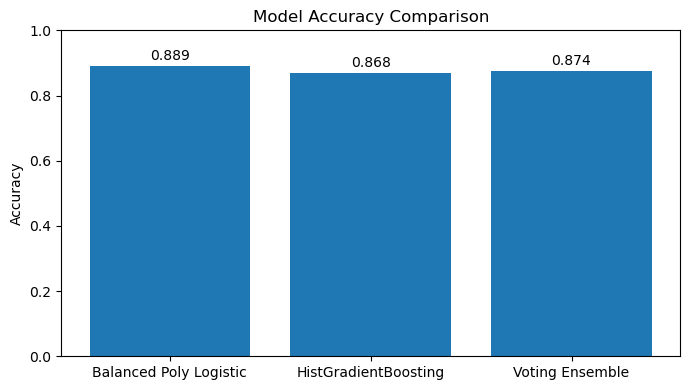


Saved figure as: model_accuracy_comparison.png


In [31]:
# Rebuild comparison_df safely (in case the previous cell wasn't run)
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# If you already have these predictions, this will just reuse them:
# poly_pred, hgb_pred, voting_pred

comparison_df = pd.DataFrame({
    "Model": ["Balanced Poly Logistic", "HistGradientBoosting", "Voting Ensemble"],
    "Accuracy": [
        accuracy_score(y_test, poly_pred),
        accuracy_score(y_test, hgb_pred),
        accuracy_score(y_test, voting_pred)
    ]
})

print("\nModel Comparison:\n", comparison_df)

# --- Bar chart ---
plt.figure(figsize=(7,4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)

# Annotate bars with accuracy values
for idx, acc in enumerate(comparison_df["Accuracy"]):
    plt.text(idx, acc + 0.01, f"{acc:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.savefig("model_accuracy_comparison.png", dpi=150)
plt.show()

print("\nSaved figure as: model_accuracy_comparison.png")



Model Comparison:
                     Model  Accuracy
0  Balanced Poly Logistic  0.889043
1    HistGradientBoosting  0.868239
2         Voting Ensemble  0.873786

Saved table to: outputs\model_comparison.csv


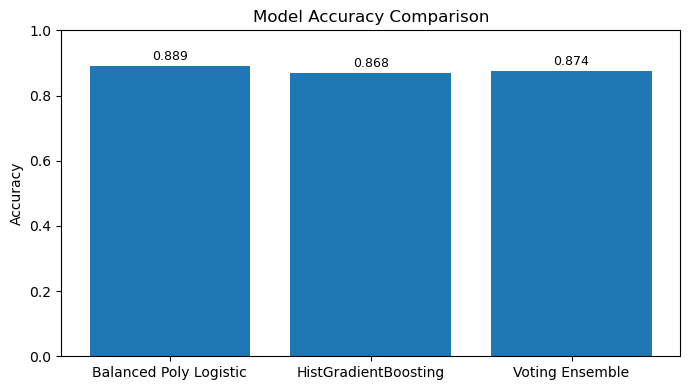

Saved figure to: outputs\model_accuracy_comparison.png


In [32]:
# Step 11: Visualization + export
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import os

# Rebuild comparison_df defensively from existing predictions
comparison_df = pd.DataFrame({
    "Model": ["Balanced Poly Logistic", "HistGradientBoosting", "Voting Ensemble"],
    "Accuracy": [
        accuracy_score(y_test, poly_pred),
        accuracy_score(y_test, hgb_pred),
        accuracy_score(y_test, voting_pred)
    ]
})

print("\nModel Comparison:\n", comparison_df)

# Save CSV
os.makedirs("outputs", exist_ok=True)
csv_path = os.path.join("outputs", "model_comparison.csv")
comparison_df.to_csv(csv_path, index=False)
print(f"\nSaved table to: {csv_path}")

# Plot
plt.figure(figsize=(7,4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)

# Annotate bars
for i, acc in enumerate(comparison_df["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
png_path = os.path.join("outputs", "model_accuracy_comparison.png")
plt.savefig(png_path, dpi=150)
plt.show()
print(f"Saved figure to: {png_path}")


Best model by accuracy: Balanced Poly Logistic (Accuracy = 0.8890)
Saved classification report to: outputs\balanced_poly_logistic_classification_report.csv


<Figure size 500x400 with 0 Axes>

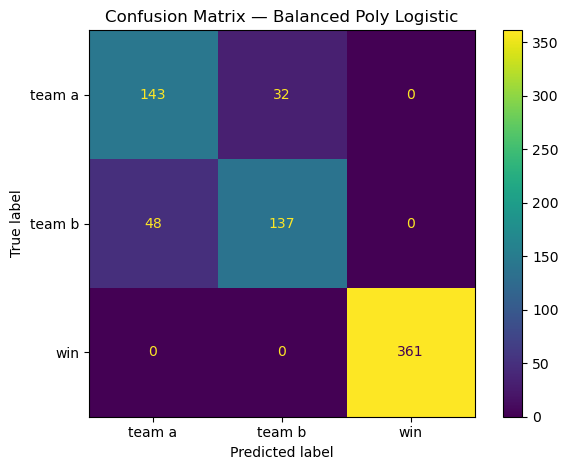

Saved confusion matrix to: outputs\balanced_poly_logistic_confusion_matrix.png


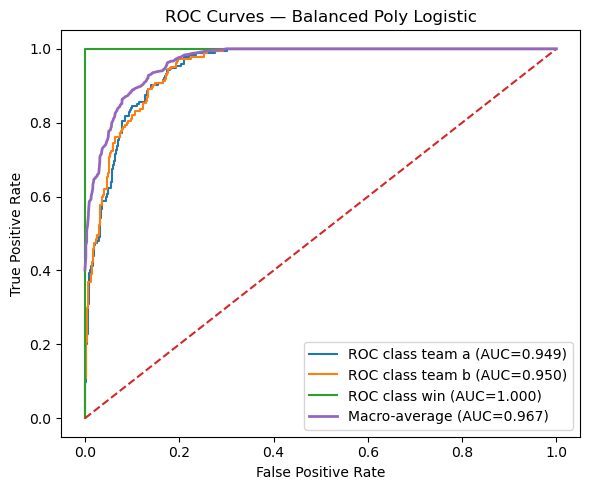

Saved ROC plot to: outputs\balanced_poly_logistic_roc.png
Macro-average ROC–AUC: 0.9670


In [33]:
# Step 12: Comprehensive evaluation & exports for the best model
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

os.makedirs("outputs", exist_ok=True)

# 1) Pick best model by accuracy among your three
acc_poly = accuracy_score(y_test, poly_pred)
acc_hgb  = accuracy_score(y_test, hgb_pred)
acc_vote = accuracy_score(y_test, voting_pred)

models = {
    "Balanced Poly Logistic": (poly_log_reg_pipeline, acc_poly),
    "HistGradientBoosting":   (hgb_model,              acc_hgb),
    "Voting Ensemble":        (voting_clf,             acc_vote),
}

best_name = max(models.items(), key=lambda kv: kv[1][1])[0]
best_model = models[best_name][0]
best_acc = models[best_name][1]

print(f"Best model by accuracy: {best_name} (Accuracy = {best_acc:.4f})")

# 2) Predictions & probabilities
y_pred = best_model.predict(X_test)
# Some estimators may not have predict_proba (they should here), handle safely:
y_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

# 3) Save classification report (CSV)
report_dict = classification_report(y_test, y_pred, target_names=le_y.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_path = os.path.join("outputs", f"{best_name.replace(' ','_').lower()}_classification_report.csv")
report_df.to_csv(report_path)
print(f"Saved classification report to: {report_path}")

# 4) Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_y.classes_)
plt.figure(figsize=(5,4))
disp.plot(values_format='d', cmap=None)
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
cm_path = os.path.join("outputs", f"{best_name.replace(' ','_').lower()}_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved confusion matrix to: {cm_path}")

# 5) Multiclass ROC (one-vs-rest) — requires probabilities
if y_proba is not None:
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)
    # Ensure proba columns align with classes order
    # (scikit-learn ensures columns correspond to classes_ order)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)
    macro_auc = auc(all_fpr, mean_tpr)

    # Plot ROC curves
    plt.figure(figsize=(6,5))
    for i, cls in enumerate(classes):
        plt.plot(fpr[i], tpr[i], label=f"ROC class {le_y.classes_[i]} (AUC={roc_auc[i]:.3f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.plot(all_fpr, mean_tpr, label=f"Macro-average (AUC={macro_auc:.3f})", linewidth=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves — {best_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    roc_path = os.path.join("outputs", f"{best_name.replace(' ','_').lower()}_roc.png")
    plt.savefig(roc_path, dpi=150)
    plt.show()
    print(f"Saved ROC plot to: {roc_path}")
    print(f"Macro-average ROC–AUC: {macro_auc:.4f}")
else:
    print("Best model does not support predict_proba; skipping ROC curves.")


In [34]:
# Step 14: Auto-generate Excel literature review
import os
import pandas as pd

os.makedirs("outputs", exist_ok=True)

rows = [
    ["Identifying player skill of Dota 2 using ML", 2024, "Dota 2",
     "Predict player skill from one match",
     "Logistic Regression, Random Forest, XGBoost",
     "OpenDota API, single-game stats",
     "Precision, Recall, F1, ROC AUC",
     "Precision ~0.71, F1 ~0.64, AUC ~0.81",
     "Only single-game; ignores team dynamics"],

    ["Real-time eSports Match Result Prediction", 2016, "Dota 2",
     "Predict winner during match progression",
     "Logistic Regression, Attribute Sequence Model",
     "78k Dota 2 matches, replay time-series",
     "Accuracy",
     "Pre-match ~59%; minute-40 ~93.7%",
     "Needs live data; stage-specific"],

    ["Machine Learning Applications in MOBA Esports – A Systematic Review", 2025, "Dota 2 / LoL",
     "Survey ML approaches for MOBA prediction",
     "Random Forest, Neural Networks, Decision Trees, Logistic Regression",
     "35 studies, multiple datasets",
     "Qualitative",
     "ML works well with simple stats; deep learning limited",
     "Dataset heterogeneity; lacks semantic features"]
]

cols = ["Title","Year","Game/Domain","Objective","Methodology",
        "Dataset","Evaluation","Result","Limitations"]

df_lit = pd.DataFrame(rows, columns=cols)
out_path = "outputs/literature_review.xlsx"
df_lit.to_excel(out_path, index=False)
print(f"Saved to: {out_path}")

# quick preview
print("\nPreview:")
print(df_lit)


Saved to: outputs/literature_review.xlsx

Preview:
                                               Title  Year   Game/Domain  \
0        Identifying player skill of Dota 2 using ML  2024        Dota 2   
1          Real-time eSports Match Result Prediction  2016        Dota 2   
2  Machine Learning Applications in MOBA Esports ...  2025  Dota 2 / LoL   

                                  Objective  \
0       Predict player skill from one match   
1   Predict winner during match progression   
2  Survey ML approaches for MOBA prediction   

                                         Methodology  \
0        Logistic Regression, Random Forest, XGBoost   
1      Logistic Regression, Attribute Sequence Model   
2  Random Forest, Neural Networks, Decision Trees...   

                                  Dataset                      Evaluation  \
0         OpenDota API, single-game stats  Precision, Recall, F1, ROC AUC   
1  78k Dota 2 matches, replay time-series                        Accuracy   